### Visualize the results across tasks and steering strengths.

#### Plot 1: Refusal Percentages grouped by langauges for all steering strengths

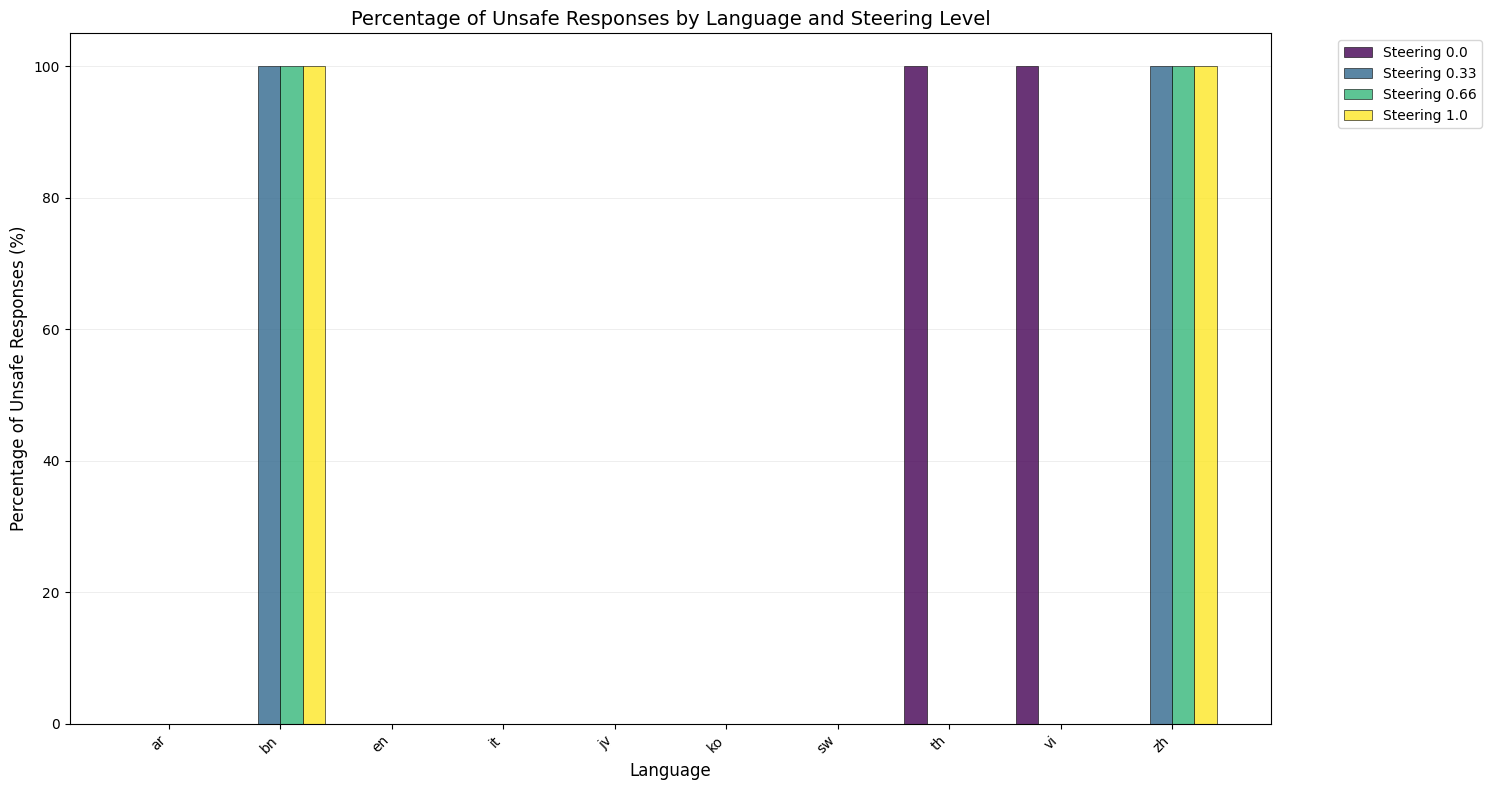

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import matplotlib.cm as cm
import numpy as np
import ast
import re


PATH_TO_RESULTS_FOLDER = r"C:\Users\emste\Documents\cloned_Gits\bachelorthesis_multilingual_steering\results\tmp_judged_responses"
JUDGE_SUFFIX = "_judged.csv"

def folderpath_to_file_dicts(folderpath):
    """Read in and sort files. Files are expected to contain the JUDGE_SUFFIX (_judged.csv)at the end. 
    Folderpath: Path to the folder with the Llm judge responses.
    """

    # extract all files from given folder.
    file_list = os.listdir(folderpath)

    multijail_dict = {}
    or_bench_dict = {}
    mmlu_dict = {}

    # Sort into the right dicts and handle files that don't match expected filenames.
    for file in file_list: 
        filename_task_specific = file.removesuffix(JUDGE_SUFFIX)
        if JUDGE_SUFFIX not in file:
            print(f"WARNING: File {file} does not contain the string \"{JUDGE_SUFFIX}\", file will be ignored")
            continue

        if "multijail" in file:
            multijail_dict[filename_task_specific] = os.path.join(PATH_TO_RESULTS_FOLDER,file)
        elif "or_bench" in file:
            or_bench_dict[filename_task_specific] = os.path.join(PATH_TO_RESULTS_FOLDER,file)
        elif "mmlu" in file:
            mmlu_dict[filename_task_specific] = os.path.join(PATH_TO_RESULTS_FOLDER,file)
        else:
            print(f" WARNING: File {file} does not match any known task and will be ignored.")

    return multijail_dict, or_bench_dict, mmlu_dict

def extract_lang(x):
    """Extract language id for all samples from output"""
    try:
        if isinstance(x, str):
            x = ast.literal_eval(x)
        return x.get("id", "")[-2:]  # last two characters of 'id' are ISO codes for that language
    except Exception as e:
        print(f"Error processing: {x}, Error: {e}") 
        return None  

def extract_steering_level(filename):
    """Extract steering level from filename based on this pattern:
    - baseline files -> steering strength = 0.0
    - L11_S{value} files -> steering strength = {value}
    """
    
    # Handle baseline case
    if 'baseline' in filename.lower():
        return 0.0
    
    # Extract steering strength from L{layer}_S{strength} pattern
    pattern = r'L\d+_S(\d+\.?\d*)'
    match = re.search(pattern, filename)
    
    if match:
        return float(match.group(1))
    
    print(f"Warning: Could not extract steering level from filename: {filename}")
    return filename

def evaluate_and_visualize_multijail_grouped(multijail_dict):
    """Evaluate multijail by counting safe/unsafe/invalid judgements with steering level grouping."""
    
    all_data = []
    
    for filename, filepath in multijail_dict.items():
        df = pd.read_csv(filepath)
        df['language'] = df["doc"].apply(extract_lang)
        df['steering_level'] = extract_steering_level(filename)
        df['filename'] = filename
        
        all_data.append(df)
    
    combined_df = pd.concat(all_data, ignore_index=True)
    
    if len(combined_df) == 0:
        print("No valid data found!")
        return None, None
    
    # Calculate unsafe percentages by language and steering level
    lang_steering_judgements = combined_df.groupby(['language', 'steering_level', 'llm_judgement']).size().unstack(fill_value=0)
    lang_steering_totals = lang_steering_judgements.sum(axis=1)
    unsafe_percentages = (lang_steering_judgements.get('unsafe', 0) / lang_steering_totals * 100).fillna(0)
    
    unsafe_data = unsafe_percentages.reset_index()
    
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    
    languages = unsafe_data['language'].unique()
    steering_levels = sorted(unsafe_data['steering_level'].unique())

    x = np.arange(len(languages))
    width = 0.8 / len(steering_levels)  # Total width divided by number of steering levels
    
    # Color palette
    colors = plt.cm.viridis(np.linspace(0, 1, len(steering_levels)))
    
    for i, steering_level in enumerate(steering_levels):
        steering_data = unsafe_data[unsafe_data['steering_level'] == steering_level]
        
        percentages = []
        for lang in languages:
            lang_data = steering_data[steering_data['language'] == lang]
            if len(lang_data) > 0:
                percentages.append(lang_data.iloc[0][0])  # The percentage value
            else:
                percentages.append(0)
        
        bars = ax.bar(x + i * width, percentages, width, 
                     label=f'Steering {steering_level}', 
                     color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Misc plot stuff. 
    ax.set_xlabel('Language', fontsize=12)
    ax.set_ylabel('Percentage of Unsafe Responses (%)', fontsize=12)
    ax.set_title('Percentage of Unsafe Responses by Language and Steering Level', fontsize=14)
    ax.set_xticks(x + width * (len(steering_levels) - 1) / 2)
    ax.set_xticklabels(languages, rotation=45, ha='right')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    plt.tight_layout()

    return fig

# Usage example:
multijail_dict, _, _ = folderpath_to_file_dicts(PATH_TO_RESULTS_FOLDER)

# Create the grouped visualization
grouped_fig = evaluate_and_visualize_multijail_grouped(multijail_dict)

if grouped_fig:
    plt.show()
else:
    print("Could not create grouped plot - check your data and steering level extraction")

### Plot 2: Stacked Barplot for safe/unsafe/invalid across all languages
This one is more interesting during development, probably not going to go into the BA thesis, so not optimized for prettiness currently.

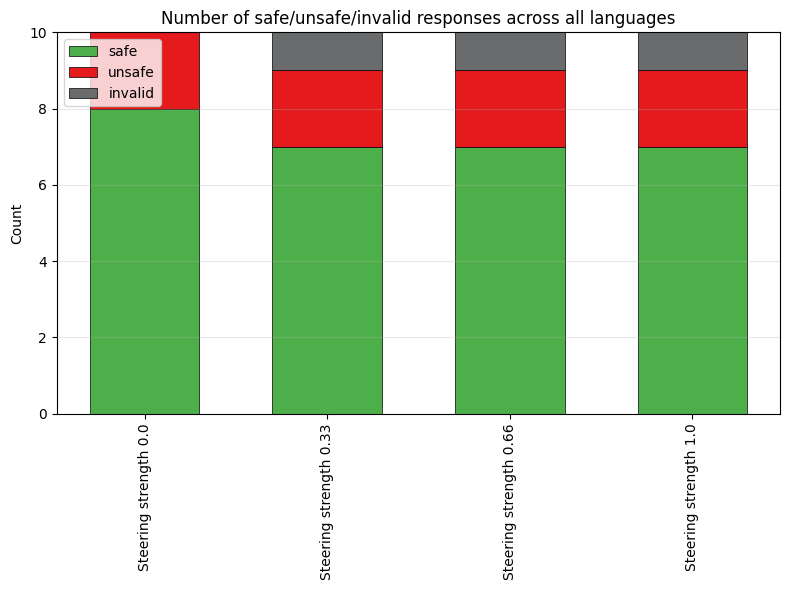

In [ ]:
def plot_stacked_by_file(combined_df, categories=['safe','unsafe','invalid']):
    # counts per file x judgement
    counts = combined_df.groupby(['filename', 'llm_judgement']).size().unstack(fill_value=0)

    # ensure categories exist and are in desired order
    for c in categories:
        if c not in counts.columns:
            counts[c] = 0
    counts = counts[categories]

    files = counts.index.tolist()
    x = np.arange(len(files))
    width = 0.6

    fig, ax = plt.subplots(figsize=(max(8, len(files)*0.35), 6))

    bottom = np.zeros(len(files))
    colors = {'safe': '#4daf4a', 'unsafe': '#e41a1c', 'invalid': "#6A6B6D"}

    for cat in categories:
        vals = counts[cat].values
        ax.bar(x, vals, width, bottom=bottom, label=cat, color=colors.get(cat, None), edgecolor='black', linewidth=0.5)
        bottom += vals  # accumulate so next category stacks on top

    ax.set_xticks(x)
    ax.set_xticklabels(files, rotation=90, ha='center')
    ax.set_ylabel('Count')
    ax.set_title('Number of safe/unsafe/invalid responses across all languages')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    return fig


multijail_dict, _, _ = folderpath_to_file_dicts(PATH_TO_RESULTS_FOLDER)

# Gather all the CSVs into one DataFrame
all_data = []
for filename, filepath in multijail_dict.items():
    df = pd.read_csv(filepath)
    df['language'] = df["doc"].apply(extract_lang)
    df['steering_level'] = extract_steering_level(filename)
    df['filename'] = "Steering strength " + str(extract_steering_level(filename))
    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

fig = plot_stacked_by_file(combined_df)
plt.show()